<!-- chandu -->
<!-- LogisticRegression -->

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("Phishing_Legitimate_full.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 50)


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 

In [14]:
df = df.drop("id", axis=1)

print("Shape after removing ID:", df.shape)

Shape after removing ID: (10000, 49)


In [15]:
print(df["CLASS_LABEL"].value_counts())

CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64


In [16]:
print(df.dtypes.value_counts())

int64      46
float64     3
Name: count, dtype: int64


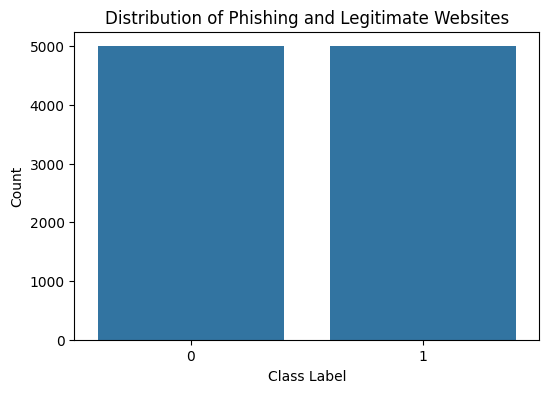

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="CLASS_LABEL", data=df)

plt.title("Distribution of Phishing and Legitimate Websites")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

In [18]:
correlation = df.corr()["CLASS_LABEL"].drop("CLASS_LABEL")

print(
    correlation.abs()
    .sort_values(ascending=False)
)

PctExtNullSelfRedirectHyperlinksRT    0.540545
FrequentDomainNameMismatch            0.463956
NumDash                               0.372235
SubmitInfoToEmail                     0.357635
PctNullSelfRedirectHyperlinks         0.342806
InsecureForms                         0.316380
NumDots                               0.294111
PctExtHyperlinks                      0.259728
NumSensitiveWords                     0.255208
IframeOrFrame                         0.235233
PathLevel                             0.229450
AbnormalExtFormActionR                0.185799
UrlLengthRT                           0.169513
HostnameLength                        0.169157
NumDashInHostname                     0.150444
NumQueryComponents                    0.147391
AbnormalFormAction                    0.145073
EmbeddedBrandName                     0.141790
IpAddress                             0.132291
DomainInPaths                         0.118201
MissingTitle                          0.116693
ExtMetaScript

In [19]:
top_corr = (
    correlation.abs()
    .sort_values(ascending=False)
    .head(15)
)

print(top_corr)

PctExtNullSelfRedirectHyperlinksRT    0.540545
FrequentDomainNameMismatch            0.463956
NumDash                               0.372235
SubmitInfoToEmail                     0.357635
PctNullSelfRedirectHyperlinks         0.342806
InsecureForms                         0.316380
NumDots                               0.294111
PctExtHyperlinks                      0.259728
NumSensitiveWords                     0.255208
IframeOrFrame                         0.235233
PathLevel                             0.229450
AbnormalExtFormActionR                0.185799
UrlLengthRT                           0.169513
HostnameLength                        0.169157
NumDashInHostname                     0.150444
Name: CLASS_LABEL, dtype: float64


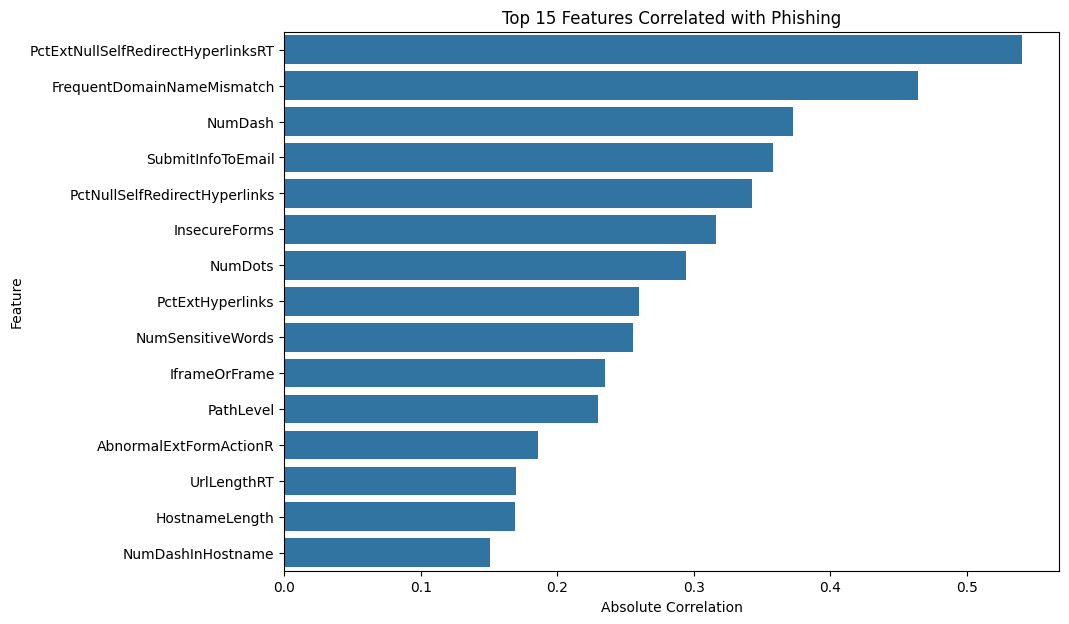

In [20]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top 15 Features Correlated with Phishing")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

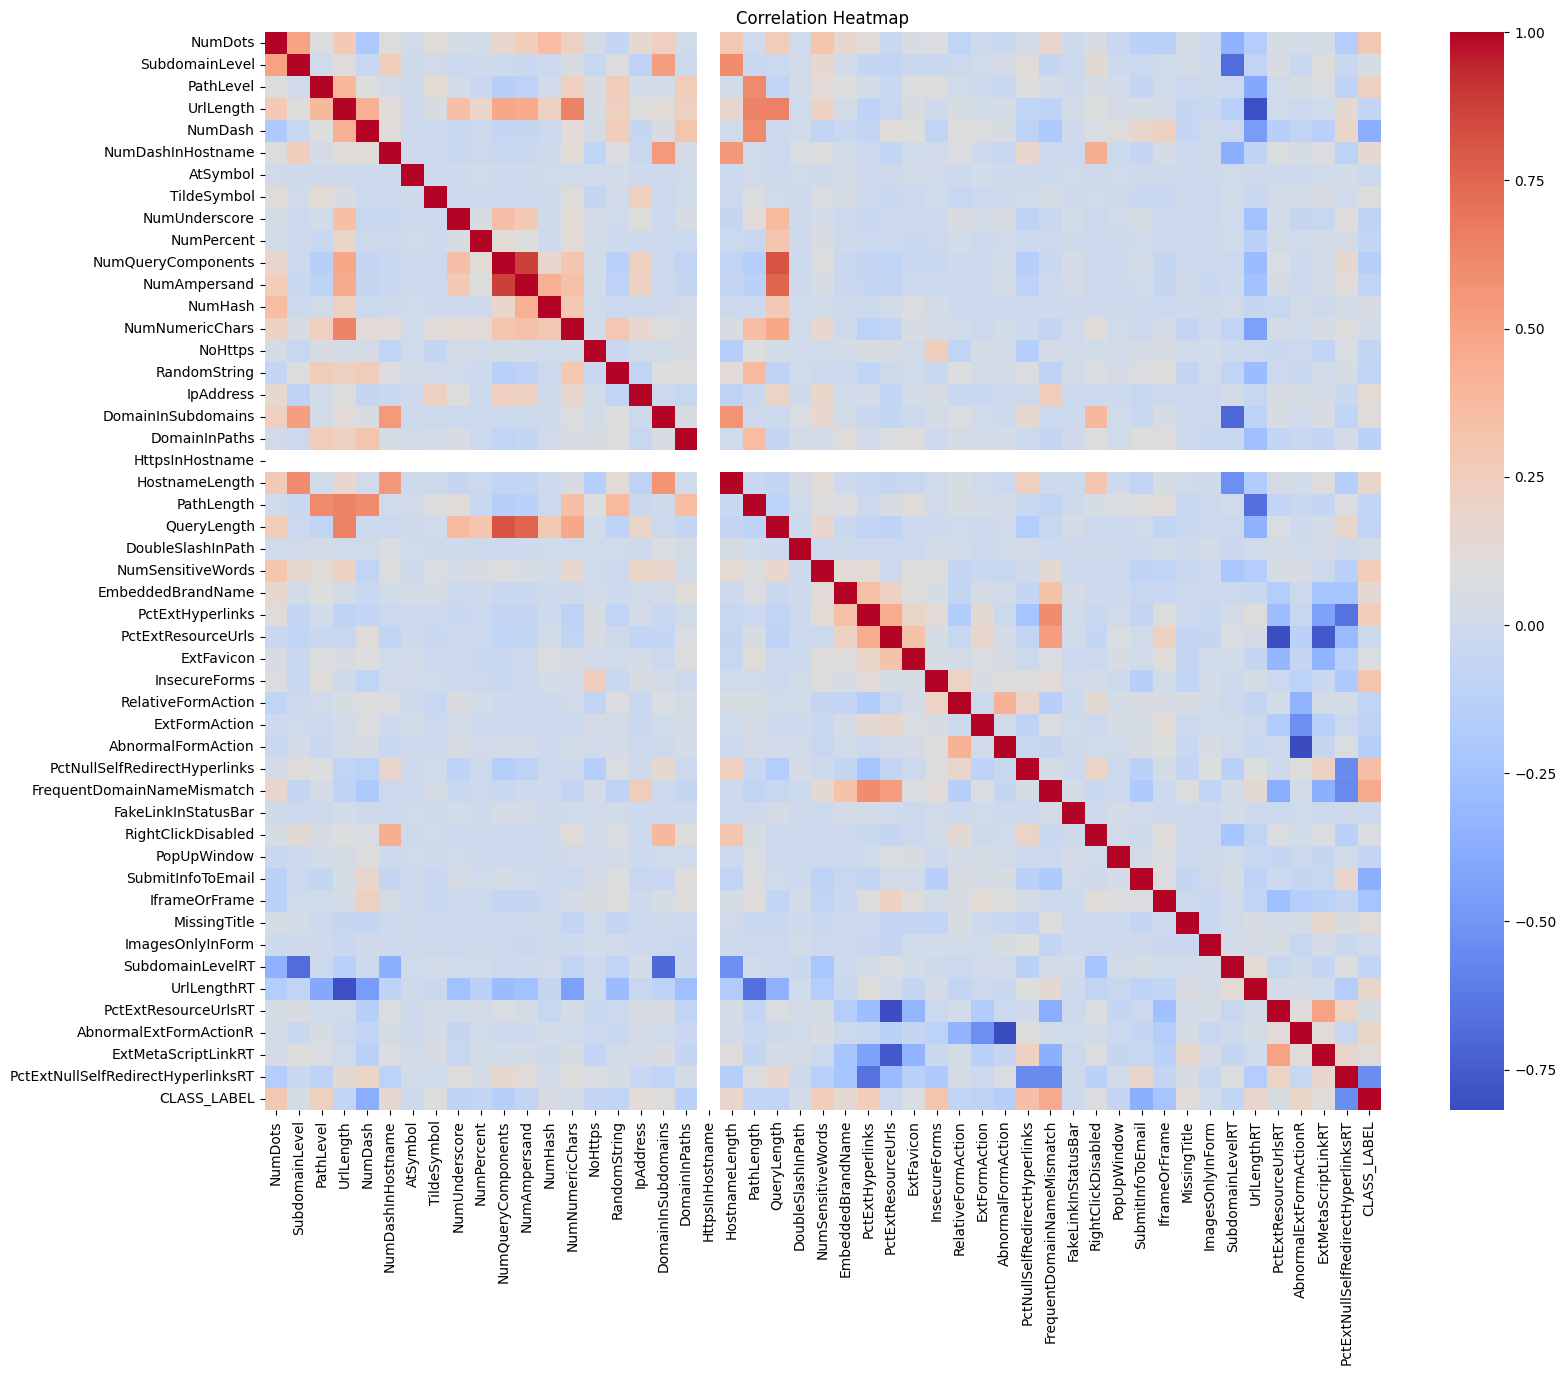

In [21]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X.columns
).sort_values(ascending=False)

print(mi_scores.head(15))

PctExtHyperlinks                      0.469465
PctExtResourceUrls                    0.293879
PctNullSelfRedirectHyperlinks         0.234187
PctExtNullSelfRedirectHyperlinksRT    0.216606
FrequentDomainNameMismatch            0.131842
NumNumericChars                       0.124515
ExtMetaScriptLinkRT                   0.121785
NumDash                               0.113250
SubmitInfoToEmail                     0.077231
PathLevel                             0.062891
NumDots                               0.061199
InsecureForms                         0.058664
QueryLength                           0.056427
PathLength                            0.054698
UrlLength                             0.041925
dtype: float64


In [23]:
# Top 15 correlation features
top_corr_features = set(
    correlation.abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Top 15 mutual information features
top_mi_features = set(
    mi_scores.head(15).index
)

# Common features
common_features = sorted(
    top_corr_features.intersection(top_mi_features)
)

print("Common important features:")
print(common_features)

print("\nNumber of common features:", len(common_features))

Common important features:
['FrequentDomainNameMismatch', 'InsecureForms', 'NumDash', 'NumDots', 'PathLevel', 'PctExtHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT', 'PctNullSelfRedirectHyperlinks', 'SubmitInfoToEmail']

Number of common features: 9


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importance.head(15))

PctExtHyperlinks                      0.189399
PctExtNullSelfRedirectHyperlinksRT    0.182074
PctExtResourceUrls                    0.078656
FrequentDomainNameMismatch            0.072827
PctNullSelfRedirectHyperlinks         0.063560
NumDash                               0.046411
NumNumericChars                       0.039055
ExtMetaScriptLinkRT                   0.033506
InsecureForms                         0.027967
SubmitInfoToEmail                     0.027137
PathLevel                             0.025815
NumDots                               0.021202
PathLength                            0.019341
NumSensitiveWords                     0.017350
UrlLength                             0.016585
dtype: float64


In [25]:
print(
    rf_importance.loc[common_features]
    .sort_values(ascending=False)
)

PctExtHyperlinks                      0.189399
PctExtNullSelfRedirectHyperlinksRT    0.182074
FrequentDomainNameMismatch            0.072827
PctNullSelfRedirectHyperlinks         0.063560
NumDash                               0.046411
InsecureForms                         0.027967
SubmitInfoToEmail                     0.027137
PathLevel                             0.025815
NumDots                               0.021202
dtype: float64


In [26]:
selected_features = [
    'FrequentDomainNameMismatch',
    'InsecureForms',
    'NumDash',
    'NumDots',
    'NumSensitiveWords',
    'PathLevel',
    'PctExtHyperlinks',
    'PctExtNullSelfRedirectHyperlinksRT',
    'PctNullSelfRedirectHyperlinks',
    'SubmitInfoToEmail'
]

In [27]:
X = df[selected_features]
y = df["CLASS_LABEL"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 10)
y shape: (10000,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (8000, 10)
X_test: (2000, 10)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 10)
X_test_scaled shape: (2000, 10)


In [30]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
y_pred = log_model.predict(X_test_scaled)

print(y_pred[:10])

[0 1 0 1 0 1 0 1 0 1]


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.907


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1000
           1       0.91      0.90      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[911  89]
 [ 97 903]]
